In [2]:
# banknotes.csv

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('banknotes.csv')
df

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [6]:
df.isnull().sum()

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

In [7]:
# check for pattern through viz

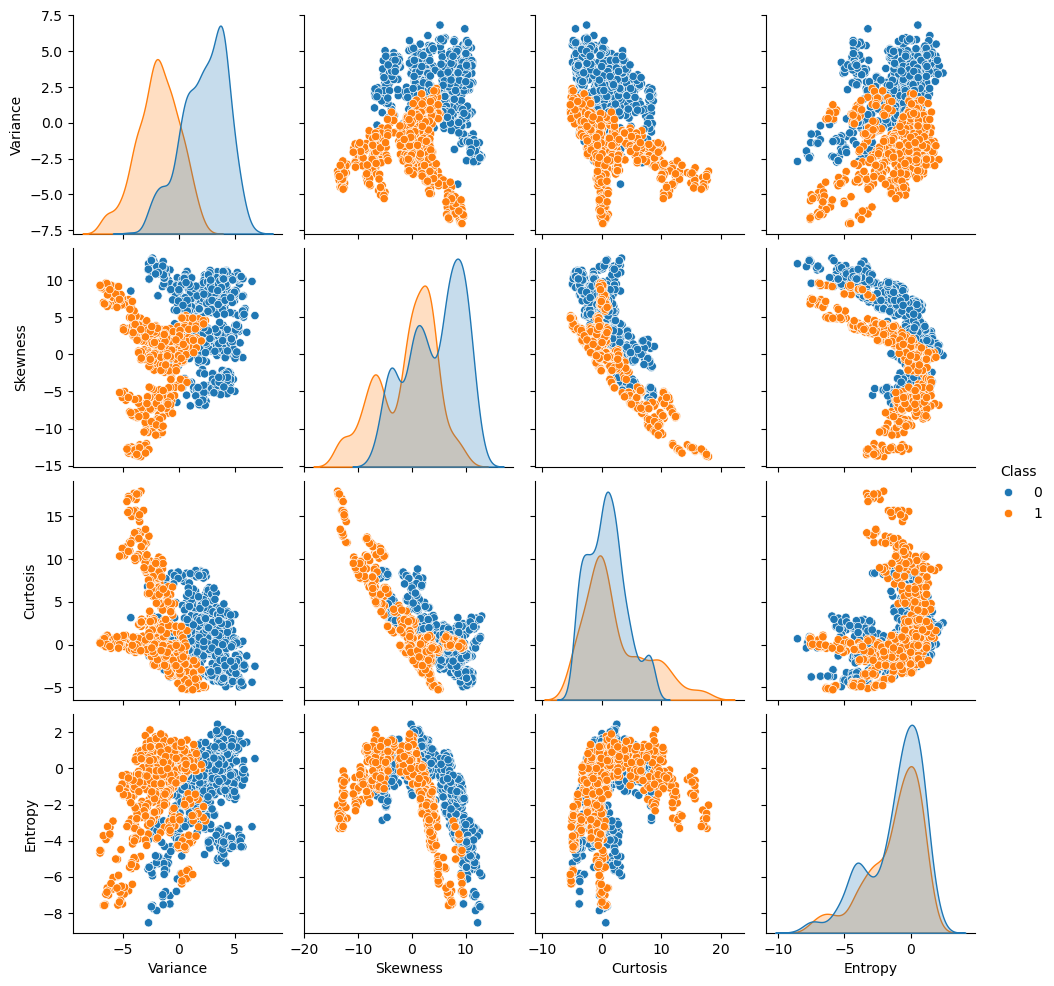

In [8]:
sns.pairplot(df, hue = 'Class')

In [9]:
# check the distrubution of target variable(countplot)

In [10]:
x =df.drop('Class', axis =1)
y = df['Class']

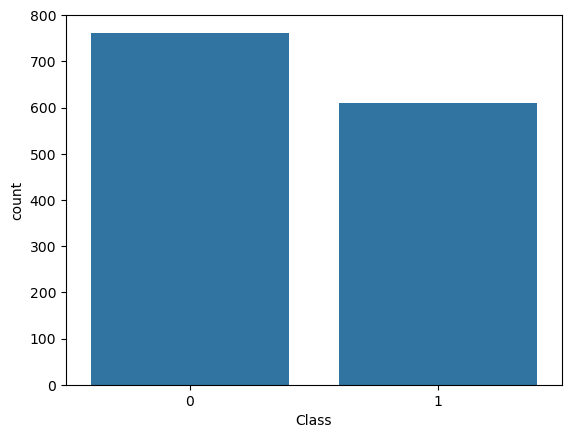

In [11]:
sns.countplot(x = y);

In [12]:
df['Class'].value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [13]:
# cross val

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    random_state=0, test_size=0.25)

In [17]:
x_train.shape, y_train.shape

((1029, 4), (1029,))

In [18]:
# build the decision tree
# and also evluate

In [19]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
# evaluate

In [21]:
y_pred = dt.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9795918367346939

In [23]:
x.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [24]:
dt.feature_importances_

array([0.6238986 , 0.20812249, 0.14189251, 0.02608639])

In [25]:
# plot the graph to viz feature importances

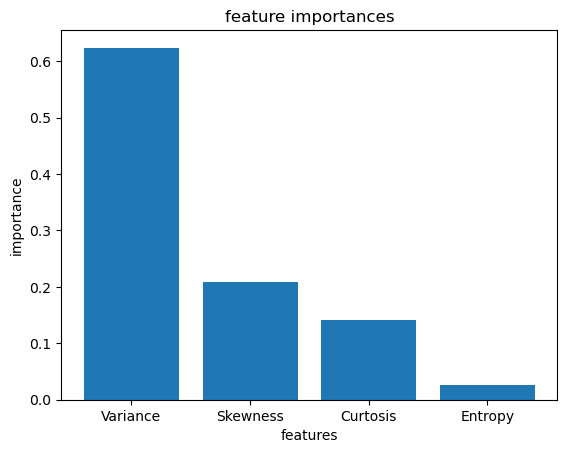

In [26]:
plt.title("feature importances")
plt.xlabel('features')
plt.ylabel("importance")
plt.bar(x.columns, dt.feature_importances_);

In [27]:
# plot the tree

In [28]:
from sklearn.tree import plot_tree

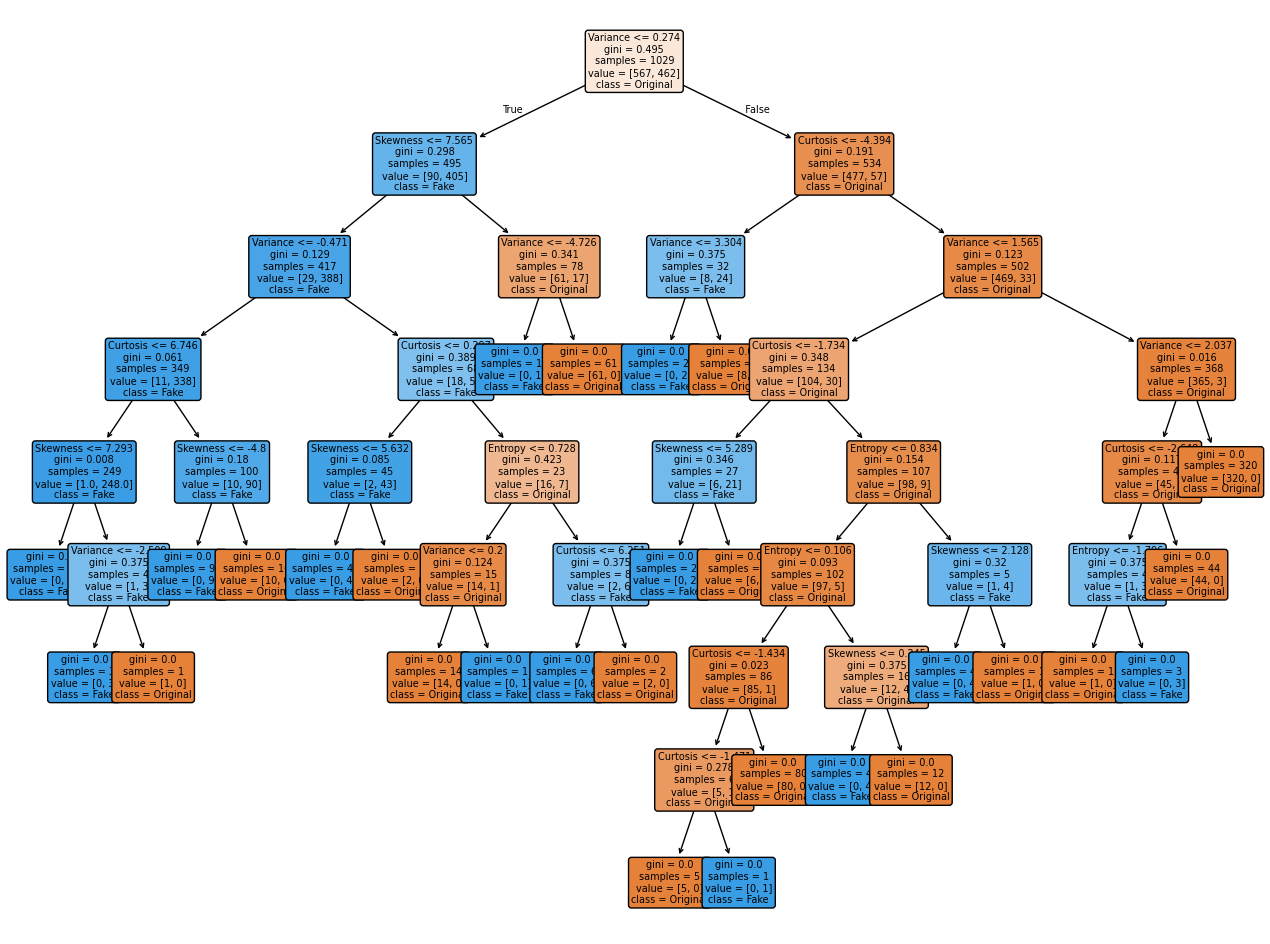

In [29]:
plt.figure(figsize=(16, 12))
plot_tree(dt, rounded= True, fontsize= 7, filled= True,
          class_names= ['Original', 'Fake'],
          feature_names= x.columns);

In [30]:
""" 
4.86600	
-1.63830
0.9242	
0.645


""";

In [31]:
new = [[4.86600	,
-1.63830,
0.9242,
0.645]]

In [32]:
dt.predict(new)

C:\Users\u\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])